# Laboratorio 9

- Mathew Alexander Cordero Aquino 22982

[Nombre del enlace](https://github.com/PedroPabloGuzmanMayen/Data_Science/tree/lab9)
 

Primero vamos ver las columnas de cada csv 

## Preparar dataset

### Juntar Hechos

In [38]:
import pandas as pd
import glob
import os

# Ruta de tus archivos
ruta = os.path.join("..", "working_dir", "hechos", "Hechos_*.csv")
archivos = sorted(glob.glob(ruta))

# Mapeo de nombres distintos a uno estándar
columnas_equivalentes = {
    'Año_ocu': 'año_ocu',
    'Día_ocu': 'día_ocu',
    'Hora_ocu': 'hora_ocu',
    'Mes_ocu': 'mes_ocu',
    'Núm_corre': 'num_corre',
    'núm_corre': 'num_corre',
    'num_correlativo': 'num_corre',
    '﻿núm_corre': 'num_corre',
    '﻿num_corre': 'num_corre',
    'día_sem_ocu': 'dia_sem_ocu',
    'día_ocu': 'dia_ocu',
    'área_geo_ocu': 'area_geo_ocu',
    'zona_ciudad': 'zona_ciudad'
}

dfs = []

for archivo in archivos:
    # Leer CSV como texto
    df = pd.read_csv(archivo, encoding='utf-8', dtype=str, low_memory=False)
    
    # Estandarizar nombres de columnas
    df.columns = [c.strip().lower() for c in df.columns]
    df.rename(columns=columnas_equivalentes, inplace=True)
    
    # Añadir columna de año si no existe
    if 'año_ocu' not in df.columns:
        df['año_ocu'] = archivo.split('_')[-1].split('.')[0]
    
    # Convertir todo a str
    df = df.astype(str)
    
    dfs.append(df)

# Concatenar todos los DataFrames: esto automáticamente añade columnas nuevas que no existían en otros archivos
hechos_total = pd.concat(dfs, ignore_index=True, sort=False)

# Convertir todo a str nuevamente, por seguridad
hechos_total = hechos_total.astype(str)

# Guardar CSV final
output_file = os.path.join("..", "working_dir", "Datos_Hechos_2013_2023.csv")
hechos_total.to_csv(output_file, index=False, encoding='utf-8')

print(f"✅ Archivo CSV guardado en: {output_file}")


✅ Archivo CSV guardado en: ../working_dir/Datos_Hechos_2013_2023.csv


In [39]:


# 1️⃣ Combinar las columnas 'causa_acc' y 'tipo_eve' en 'tipo_accidente'
hechos_total['tipo_accidente'] = hechos_total[['causa_acc', 'tipo_eve']].apply(
    lambda x: ' '.join([str(i) for i in x if pd.notna(i) and str(i).lower() != 'nan']).strip(),
    axis=1
)

# 2️⃣ Conservar solo las columnas deseadas
columnas_finales = [
    'dia_ocu', 'mes_ocu', 'año_ocu', 'hora_ocu',
    'depto_ocu', 'mupio_ocu', 'tipo_veh',
    'color_veh', 'modelo_veh', 'tipo_accidente', 'marca_veh'
]

# Crear columnas vacías si faltan
for col in columnas_finales:
    if col not in hechos_total.columns:
        hechos_total[col] = ''

hechos_total = hechos_total[columnas_finales]

# 3️⃣ Guardar CSV final
output_file = os.path.join("..", "working_dir", "Datos_Hechos_2013_2023.csv")
hechos_total.to_csv(output_file, index=False, encoding='utf-8')

print(f"✅ Archivo CSV guardado en: {output_file}")


✅ Archivo CSV guardado en: ../working_dir/Datos_Hechos_2013_2023.csv


### Juntar Lesionados

In [37]:
import pandas as pd
import glob
import os
import numpy as np

ruta_lesionados = os.path.join("..", "working_dir", "lesionados", "Lesionados_*.csv")
archivos_lesionados = sorted(glob.glob(ruta_lesionados))

columnas_equivalentes_lesionados = {
    'num_hecho': 'num_corre',
    'num_correlativo': 'num_corre',
    'núm_corre': 'num_corre',
    '\ufeff\ufeffnum_corre': 'num_corre',
    '\ufeff\ufeffnúm_corre': 'num_corre',
    
    'tipo_eve': 'tipo_lesion',
    'tipo_lesion': 'tipo_lesion',
    'tipo_eve_cod': 'tipo_lesion',
    
    'sexo_per': 'sexo',
    'sexo_víc': 'sexo',
    'sexo_pil': 'sexo',
    
    'edad_per': 'edad',
    'edad_pil': 'edad',
    'edad_víc': 'edad',
    'edad_quinquenales': 'edad',
    
    'área_geo_ocu': 'area_geo_ocu',
    'areag_ocu': 'area_geo_ocu'
}

dfs_lesionados = []

for archivo in archivos_lesionados:
    df = pd.read_csv(archivo, encoding='utf-8', dtype=str, low_memory=False)
    
    # Estandarizar nombres
    df.columns = [c.strip().lower() for c in df.columns]
    df.rename(columns=columnas_equivalentes_lesionados, inplace=True)
    
    # Añadir año si no existe
    if 'año_ocu' not in df.columns:
        df['año_ocu'] = archivo.split('_')[-1].split('.')[0]
    
    # Convertir todo a str
    df = df.astype(str)
    
    # Eliminar columnas duplicadas, manteniendo la primera aparición
    df = df.loc[:, ~df.columns.duplicated()]
    
    dfs_lesionados.append(df)

# Concatenar DataFrames ya limpios
lesionados_total = pd.concat(dfs_lesionados, ignore_index=True, sort=False)

# Reemplazar strings vacíos o 'nan' por NaN
lesionados_total = lesionados_total.replace({'': np.nan, 'nan': np.nan})

# Guardar CSV final
output_file_lesionados = os.path.join("..", "working_dir", "Datos_Lesionados_2013_2023.csv")
lesionados_total.to_csv(output_file_lesionados, index=False, encoding='utf-8')

print(f"✅ Archivo CSV de lesionados guardado en: {output_file_lesionados}")


✅ Archivo CSV de lesionados guardado en: ../working_dir/Datos_Lesionados_2013_2023.csv


In [41]:


# Leer el CSV ya existente
input_file = os.path.join("..", "working_dir", "Datos_Lesionados_2013_2023.csv")
lesionados_total = pd.read_csv(input_file, dtype=str, encoding='utf-8')

# Convertir todo a str
lesionados_total = lesionados_total.astype(str)

# Combinar columnas equivalentes: día_ocu
if 'día_ocu' in lesionados_total.columns and 'dia_ocu' in lesionados_total.columns:
    lesionados_total['dia_ocu'] = lesionados_total[['día_ocu', 'dia_ocu']].apply(
        lambda x: next((v for v in x if v and v.lower() != 'nan'), np.nan), axis=1
    )
    lesionados_total.drop(columns=['día_ocu'], inplace=True)
elif 'día_ocu' in lesionados_total.columns:
    lesionados_total.rename(columns={'día_ocu': 'dia_ocu'}, inplace=True)

# Combinar columnas equivalentes: fall_les y fallecidos_lesionados
if 'fall_les' in lesionados_total.columns and 'fallecidos_lesionados' in lesionados_total.columns:
    lesionados_total['fallecidos_lesionados'] = lesionados_total[['fall_les', 'fallecidos_lesionados']].apply(
        lambda x: next((v for v in x if v and v.lower() != 'nan'), np.nan), axis=1
    )
    lesionados_total.drop(columns=['fall_les'], inplace=True)
elif 'fall_les' in lesionados_total.columns:
    lesionados_total.rename(columns={'fall_les': 'fallecidos_lesionados'}, inplace=True)

# Columnas a conservar en el orden deseado
columnas_finales = [
    'num_corre', 'dia_ocu', 'mes_ocu', 'hora_ocu', 'depto_ocu', 'mupio_ocu',
    'año_ocu', 'tipo_veh', 'marca_veh', 'color_veh', 'modelo_veh', 'edad',
    'fallecidos_lesionados'  # si quieres conservar esta columna combinada
]

# Crear columnas faltantes si no existen
for col in columnas_finales:
    if col not in lesionados_total.columns:
        lesionados_total[col] = np.nan

# Reordenar columnas
lesionados_total = lesionados_total[columnas_finales]

# Guardar CSV final limpio
output_file = os.path.join("..", "working_dir", "Datos_Lesionados_2013_2023.csv")
lesionados_total.to_csv(output_file, index=False, encoding='utf-8')

print(f"✅ CSV limpio de lesionados guardado en: {output_file}")


✅ CSV limpio de lesionados guardado en: ../working_dir/Datos_Lesionados_2013_2023.csv


### Juntar todos en un dataset

In [42]:
import pandas as pd

# Rutas de los archivos
archivo_hechos = "../working_dir/Datos_Hechos_2013_2023.csv"
archivo_lesionados = "../working_dir/Datos_Lesionados_2013_2023.csv"

# Leer solo los encabezados para ver columnas
df_hechos = pd.read_csv(archivo_hechos, nrows=0, dtype=str, encoding='utf-8')
df_lesionados = pd.read_csv(archivo_lesionados, nrows=0, dtype=str, encoding='utf-8')

print("Columnas de Datos_Hechos_2013_2023:")
print(df_hechos.columns.tolist())
print("-" * 50)

print("Columnas de Datos_Lesionados_2013_2023:")
print(df_lesionados.columns.tolist())
print("-" * 50)


Columnas de Datos_Hechos_2013_2023:
['dia_ocu', 'mes_ocu', 'año_ocu', 'hora_ocu', 'depto_ocu', 'mupio_ocu', 'tipo_veh', 'color_veh', 'modelo_veh', 'tipo_accidente', 'marca_veh']
--------------------------------------------------
Columnas de Datos_Lesionados_2013_2023:
['num_corre', 'dia_ocu', 'mes_ocu', 'hora_ocu', 'depto_ocu', 'mupio_ocu', 'año_ocu', 'tipo_veh', 'marca_veh', 'color_veh', 'modelo_veh', 'edad', 'fallecidos_lesionados']
--------------------------------------------------


In [43]:
import pandas as pd

# Ruta del archivo de lesionados
archivo_lesionados = "../working_dir/Datos_Lesionados_2013_2023.csv"

# Leer solo la columna relevante como texto
df_lesionados = pd.read_csv(archivo_lesionados, usecols=['fallecidos_lesionados'], dtype=str, encoding='utf-8')

# Ver valores únicos
valores_unicos = df_lesionados['fallecidos_lesionados'].unique()
print("Valores únicos en 'fallecidos_lesionados':")
print(valores_unicos)

# Opcional: contar cuántas veces aparece cada valor
conteo_valores = df_lesionados['fallecidos_lesionados'].value_counts(dropna=False)
print("\nConteo de cada valor:")
print(conteo_valores)


Valores únicos en 'fallecidos_lesionados':
['2.0' '1.0' '2' '1' '12' '3' '4' '5' '6' '7' '8' '9' '10' '11'
 'Lesionado' 'Fallecido' 'Ignorado']

Conteo de cada valor:
fallecidos_lesionados
2            49993
Lesionado    17466
2.0          15940
1            11038
Fallecido     4451
1.0           3664
3             1468
4             1194
5              944
6              728
11             655
7              489
8              391
12             374
9              355
10             264
Ignorado         3
Name: count, dtype: int64


In [31]:


# Rutas
archivo_hechos = "../working_dir/Datos_Hechos_2013_2023.csv"
archivo_lesionados = "../working_dir/Datos_Lesionados_2013_2023.csv"
archivo_salida = "../working_dir/Datos_Accidentes_2013_2023.csv"

# Leer CSVs
df_hechos = pd.read_csv(archivo_hechos, dtype=str, encoding='utf-8')
df_lesionados = pd.read_csv(archivo_lesionados, dtype=str, encoding='utf-8')

# Columnas clave
key_cols = ['dia_ocu', 'mes_ocu', 'hora_ocu', 'depto_ocu', 'mupio_ocu', 'año_ocu']

# --- Normalizar columna fallecidos_lesionados ---
def contar_fallecidos(x):
    x = str(x).strip()
    if x in ['1', '1.0', 'Fallecido']:
        return 1
    else:
        return 0

def contar_lesionados(x):
    x = str(x).strip()
    if x in ['2', '2.0', 'Lesionado']:
        return 1
    elif x.isdigit() and int(x) > 2:
        return int(x)
    else:
        return 0

df_lesionados['fallecidos'] = df_lesionados['fallecidos_lesionados'].apply(contar_fallecidos)
df_lesionados['lesionados'] = df_lesionados['fallecidos_lesionados'].apply(contar_lesionados)

# --- Agrupar por accidente y sumar ---
lesionados_fallecidos = (
    df_lesionados
    .groupby(key_cols)[['fallecidos', 'lesionados']]
    .sum()
    .reset_index()
)

# --- Contar vehículos involucrados ---
vehiculos_por_accidente = (
    df_hechos
    .groupby(key_cols)['tipo_veh']
    .nunique()
    .reset_index()
    .rename(columns={'tipo_veh': 'numero_vehiculos_involucrados'})
)

# --- Unir ambos DataFrames ---
df_final = pd.merge(vehiculos_por_accidente, lesionados_fallecidos, on=key_cols, how='outer')

# --- Rellenar valores faltantes ---
df_final['numero_vehiculos_involucrados'] = df_final['numero_vehiculos_involucrados'].fillna(1).astype(int)
df_final['fallecidos'] = df_final['fallecidos'].fillna(0).astype(int)
df_final['lesionados'] = df_final['lesionados'].fillna(0).astype(int)

# --- Ordenar cronológicamente ---
df_final = df_final.sort_values(by=['año_ocu', 'mes_ocu', 'dia_ocu', 'hora_ocu']).reset_index(drop=True)

# --- Guardar en CSV ---
df_final.to_csv(archivo_salida, index=False, encoding='utf-8')

print(f"Archivo guardado en: {archivo_salida}")


Archivo guardado en: ../working_dir/Datos_Accidentes_2013_2023.csv


In [32]:
from unidecode import unidecode

def normalizar_valores_map(original_map):
    
    return {k: unidecode(v).lower().strip() for k, v in original_map.items()}


muni_map = {
    101: 'Guatemala',
    102: 'Santa Catarina Pinula',
    103: 'San José Pinula',
    104: 'San José del Golfo',
    105: 'Palencia',
    106: 'Chinautla',
    107: 'San Pedro Ayampuc',
    108: 'Mixco',
    109: 'San Pedro Sacatepéquez',
    110: 'San Juan Sacatepéquez',
    111: 'San Raymundo',
    112: 'Chuarrancho',
    113: 'Fraijanes',
    114: 'Amatitlán',
    115: 'Villa Nueva',
    116: 'Villa Canales',
    117: 'Petapa',
    201: 'Guastatoya',
    202: 'Morazán',
    203: 'San Agustín Acasaguastlán',
    204: 'San Cristóbal Acasaguastlán',
    205: 'El Jícaro',
    206: 'Sansare',
    207: 'Sanarate',
    208: 'San Antonio la Paz',
    301: 'Antigua Guatemala',
    302: 'Jocotenango',
    303: 'Pastores',
    304: 'Sumpango',
    305: 'Santo Domingo Xenacoj',
    306: 'Santiago Sacatepéquez',
    307: 'San Bartolomé Milpas Altas',
    308: 'San Lucas Sacatepéquez',
    309: 'Santa Lucía Milpas Altas',
    310: 'Magdalena Milpas Altas',
    311: 'Santa María de Jesús',
    312: 'Ciudad Vieja',
    313: 'San Miguel Dueñas',
    314: 'San Juan Alotenango',
    315: 'San Antonio Aguas Calientes',
    316: 'Santa Catarina Barahona',
    401: 'Chimaltenango',
    402: 'San José Poaquíl',
    403: 'San Martín Jilotepeque',
    404: 'Comalapa',
    405: 'Santa Apolonia',
    406: 'Tecpán Guatemala',
    407: 'Patzún',
    408: 'San Miguel Pochuta',
    409: 'Patzicía',
    410: 'Santa Cruz Balanyá',
    411: 'Acatenango',
    412: 'Yepocapa',
    413: 'San Andrés Itzapa',
    414: 'Parramos',
    415: 'Zaragoza',
    416: 'El Tejar',
    501: 'Escuintla',
    502: 'Santa Lucía Cotzumalguapa',
    503: 'La Democracia',
    504: 'Siquinalá',
    505: 'Masagua',
    506: 'Tiquisate',
    507: 'La Gomera',
    508: 'Guanagazapa',
    509: 'San José',
    510: 'Iztapa',
    511: 'Palín',
    512: 'San Vicente Pacaya',
    513: 'Nueva Concepción',
    514: 'Sipacate',
    601: 'Cuilapa',
    602: 'Barberena',
    603: 'Santa Rosa de Lima',
    604: 'Casillas',
    605: 'San Rafael las Flores',
    606: 'Oratorio',
    607: 'San Juan Tecuaco',
    608: 'Chiquimulilla',
    609: 'Taxisco',
    610: 'Santa María Ixhuatán',
    611: 'Guazacapán',
    612: 'Santa Cruz el Naranjo',
    613: 'Pueblo Nuevo Viñas',
    614: 'Nueva Santa Rosa',
    701: 'Sololá',
    702: 'San José Chacayá',
    703: 'Santa María Visitación',
    704: 'Santa Lucía Utatlán',
    705: 'Nahualá',
    706: 'Santa Catarina Ixtahuacán',
    707: 'Santa Clara la Laguna',
    708: 'Concepción',
    709: 'San Andrés Semetabaj',
    710: 'Panajachel',
    711: 'Santa Catarina Palopó',
    712: 'San Antonio Palopó',
    713: 'San Lucas Tolimán',
    714: 'Santa Cruz la Laguna',
    715: 'San Pablo la Laguna',
    716: 'San Marcos la Laguna',
    717: 'San Juan la Laguna',
    718: 'San Pedro la Laguna',
    719: 'Santiago Atitlán',
    801: 'Totonicapán',
    802: 'San Cristóbal Totonicapán',
    803: 'San Francisco el Alto',
    804: 'San Andrés Xecul',
    805: 'Momostenango',
    806: 'Santa María Chiquimula',
    807: 'Santa Lucía la Reforma',
    808: 'San Bartolo Aguas Calientes',
    901: 'Quetzaltenango',
    902: 'Salcajá',
    903: 'Olintepeque',
    904: 'San Carlos Sija',
    905: 'Sibilia',
    906: 'Cabricán',
    907: 'Cajolá',
    908: 'San Miguel Siguilá',
    909: 'San Juan Ostuncalco',
    910: 'San Mateo',
    911: 'Concepción Chiquirichapa',
    912: 'San Martín Sacatepéquez',
    913: 'Almolonga',
    914: 'Cantel',
    915: 'Huitán',
    916: 'Zunil',
    917: 'Colomba',
    918: 'San Francisco la Unión',
    919: 'El Palmar',
    920: 'Coatepeque',
    921: 'Génova',
    922: 'Flores Costa Cuca',
    923: 'La Esperanza',
    924: 'Palestina de los Altos',
    1001: 'Mazatenango',
    1002: 'Cuyotenango',
    1003: 'San Francisco Zapotitlán',
    1004: 'San Bernardino',
    1005: 'San José el Ídolo',
    1006: 'Santo Domingo Suchitepéquez',
    1007: 'San Lorenzo',
    1008: 'Samayac',
    1009: 'San Pablo Jocopilas',
    1010: 'San Antonio Suchitepéquez',
    1011: 'San Miguel Panán',
    1012: 'San Gabriel',
    1013: 'Chicacao',
    1014: 'Patulul',
    1015: 'Santa Bárbara',
    1016: 'San Juan Bautista',
    1017: 'Santo Tomas la Unión',
    1018: 'Zunilito',
    1019: 'Pueblo Nuevo',
    1020: 'Río Bravo',
    1021: 'San José La Máquina',
    1101: 'Retalhuleu',
    1102: 'San Sebastián',
    1103: 'Santa Cruz Muluá',
    1104: 'San Martín Zapotitlán',
    1105: 'San Felipe Retalhuleu',
    1106: 'San Andrés Villa Seca',
    1107: 'Champerico',
    1108: 'Nuevo San Carlos',
    1109: 'El Asintal',
    1201: 'San Marcos',
    1202: 'San Pedro Sacatepéquez',
    1203: 'San Antonio Sacatepéquez',
    1204: 'Comitancillo',
    1205: 'San Miguel Ixtahuacán',
    1206: 'Concepción Tutuapa',
    1207: 'Tacaná',
    1208: 'Sibinal',
    1209: 'Tajumulco',
    1210: 'Tejutla',
    1211: 'San Rafael Pie de la Cuesta',
    1212: 'Nuevo Progreso',
    1213: 'El Tumbador',
    1214: 'El Rodeo',
    1215: 'Malacatán',
    1216: 'Catarina',
    1217: 'Ayutla',
    1218: 'Ocós',
    1219: 'San Pablo',
    1220: 'El Quetzal',
    1221: 'La Reforma',
    1222: 'Pajapita',
    1223: 'Ixchiguán',
    1224: 'San José Ojetenam',
    1225: 'San Cristóbal Cucho',
    1226: 'Sipacapa',
    1227: 'Esquipulas Palo Gordo',
    1228: 'Río Blanco',
    1229: 'San Lorenzo',
    1230: 'La Blanca',
    1301: 'Huehuetenango',
    1302: 'Chiantla',
    1303: 'Malacatancito',
    1304: 'Cuilco',
    1305: 'Nentón',
    1306: 'San Pedro Necta',
    1307: 'Jacaltenango',
    1308: 'San Pedro Soloma',
    1309: 'San Ildefonso Ixtahuacán',
    1310: 'Santa Bárbara',
    1311: 'La Libertad',
    1312: 'La Democracia',
    1313: 'San Miguel Acatán',
    1314: 'San Rafael La Independencia',
    1315: 'Todos Santos Cuchumatán',
    1316: 'San Juan Atitán',
    1317: 'Santa Eulalia',
    1318: 'San Mateo Ixtatán',
    1319: 'Colotenango',
    1320: 'San Sebastián Huehuetenango',
    1321: 'Tectitán',
    1322: 'Concepción Huista',
    1323: 'San Juan Ixcoy',
    1324: 'San Antonio Huista',
    1325: 'San Sebastián Coatán',
    1326: 'Barrillas',
    1327: 'Aguacatán',
    1328: 'San Rafael Petzal',
    1329: 'San Gaspar Ixchil',
    1330: 'Santiago Chimaltenango',
    1331: 'Santa Ana Huista',
    1332: 'Unión Cantinil',
    1333: 'Petatán',
    1401: 'Santa Cruz del Quiché',
    1402: 'Chiché',
    1403: 'Chinique',
    1404: 'Zacualpa',
    1405: 'Chajul',
    1406: 'Chichicastenango',
    1407: 'Patzité',
    1408: 'San Antonio Ilotenango',
    1409: 'San Pedro Jocopilas',
    1410: 'Cunén',
    1411: 'San Juan Cotzal',
    1412: 'Joyabaj',
    1413: 'Santa María Nebaj',
    1414: 'San Andrés Sajcabajá',
    1415: 'San Miguel Uspantán',
    1416: 'Sacapulas',
    1417: 'San Bartolomé Jocotenango',
    1418: 'Canillá',
    1419: 'Chicamán',
    1420: 'Ixcán',
    1421: 'Pachalum',
    1501: 'Salamá',
    1502: 'San Miguel Chicaj',
    1503: 'Rabinal',
    1504: 'Cubulco',
    1505: 'Granados',
    1506: 'El Chol',
    1507: 'San Jerónimo',
    1508: 'Purulhá',
    1601: 'Cobán',
    1602: 'Santa Cruz Verapaz',
    1603: 'San Cristóbal Verapaz',
    1604: 'Tactic',
    1605: 'Tamahú',
    1606: 'Tucurú',
    1607: 'Panzós',
    1608: 'Senahú',
    1609: 'San Pedro Carchá',
    1610: 'San Juan Chamelco',
    1611: 'Lanquín',
    1612: 'Cahabón',
    1613: 'Chisec',
    1614: 'Chahal',
    1615: 'Fray Bartolomé de las Casas',
    1616: 'Santa Catarina La Tinta',
    1617: 'Raxruhá',
    1701: 'Flores',
    1702: 'San José',
    1703: 'San Benito',
    1704: 'San Andrés',
    1705: 'La Libertad',
    1706: 'San Francisco',
    1707: 'Santa Ana',
    1708: 'Dolores',
    1709: 'San Luis',
    1710: 'Sayaxché',
    1711: 'Melchor de Mencos',
    1712: 'Poptún',
    1713: 'Las Cruces',
    1714: 'El Chal',
    1801: 'Puerto Barrios',
    1802: 'Livingston',
    1803: 'El Estor',
    1804: 'Morales',
    1805: 'Los Amates',
    1901: 'Zacapa',
    1902: 'Estanzuela',
    1903: 'Río Hondo',
    1904: 'Gualán',
    1905: 'Teculután',
    1906: 'Usumatlán',
    1907: 'Cabañas',
    1908: 'San Diego',
    1909: 'La Unión',
    1910: 'Huité',
    1911: 'San Jorge',
    2001: 'Chiquimula',
    2002: 'San José la Arada',
    2003: 'San Juan Ermita',
    2004: 'Jocotán',
    2005: 'Camotán',
    2006: 'Olopa',
    2007: 'Esquipulas',
    2008: 'Concepción las Minas',
    2009: 'Quezaltepeque',
    2010: 'San Jacinto',
    2011: 'Ipala',
    2101: 'Jalapa',
    2102: 'San Pedro Pinula',
    2103: 'San Luis Jilotepeque',
    2104: 'San Manuel Chaparrón',
    2105: 'San Carlos Alzatate',
    2106: 'Monjas',
    2107: 'Mataquescuintla',
    2201: 'Jutiapa',
    2202: 'El Progreso',
    2203: 'Santa Catarina Mita',
    2204: 'Agua Blanca',
    2205: 'Asunción Mita',
    2206: 'Yupiltepeque',
    2207: 'Atescatempa',
    2208: 'Jerez',
    2209: 'El Adelanto',
    2210: 'Zapotitlán',
    2211: 'Comapa',
    2212: 'Jalpatagua',
    2213: 'Conguaco',
    2214: 'Moyuta',
    2215: 'Pasaco',
    2216: 'San José Acatempa',
    2217: 'Quesada'
}

muni_map = normalizar_valores_map(muni_map)


In [40]:
import pandas as pd
from unidecode import unidecode

# --- Función para limpiar texto ---
def limpiar_texto(texto):
    if pd.isna(texto):
        return None
    return unidecode(str(texto)).strip().lower()  # quita tildes, pasa a minúsculas y elimina espacios

# --- Cargar dataset ---
archivo_accidentes = "../working_dir/Datos_Accidentes_2013_2023.csv"
df = pd.read_csv(archivo_accidentes, dtype=str, encoding='utf-8')

# --- Limpiar columnas de texto ---
for col in ['mes_ocu', 'depto_ocu', 'mupio_ocu']:
    df[col] = df[col].apply(limpiar_texto)

# --- Mapeo de meses a números (acepta 'setiembre' también) ---
meses_map = {
    'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
    'julio': 7, 'agosto': 8, 'septiembre': 9, 'setiembre': 9,
    'octubre': 10, 'noviembre': 11, 'diciembre': 12
}

# Reemplazar nombres de meses por números (con función)
def convertir_mes(valor):
    if pd.isna(valor):
        return None
    if valor in meses_map:
        return meses_map[valor]
    # Si es número en texto
    valor = valor.replace('.0', '')
    if valor.isdigit():
        return int(valor)
    return None

df['mes_ocu'] = df['mes_ocu'].apply(convertir_mes).astype('Int64')

# --- Mapeo de departamentos a números ---
depto_map = {
    'guatemala': 1, 'el progreso': 2, 'sacatepequez': 3, 'chimaltenango': 4, 'escuintla': 5,
    'santa rosa': 6, 'solola': 7, 'totonicapan': 8, 'quetzaltenango': 9, 'suchitepequez': 10,
    'retalhuleu': 11, 'san marcos': 12, 'huehuetenango': 13, 'quiche': 14, 'baja verapaz': 15,
    'alta verapaz': 16, 'peten': 17, 'izabal': 18, 'zacapa': 19, 'chiquimula': 20,
    'jalapa': 21, 'jutiapa': 22
}

df['depto_ocu'] = df['depto_ocu'].replace(depto_map)
df['depto_ocu'] = pd.to_numeric(df['depto_ocu'], errors='coerce').astype('Int64')

# --- Mapeo municipios ---
# (Asegúrate de que muni_map esté definido antes)
muni_map_invertido = {unidecode(v).strip().lower(): k for k, v in muni_map.items()}
df['mupio_ocu'] = df['mupio_ocu'].replace(muni_map_invertido)
df['mupio_ocu'] = pd.to_numeric(df['mupio_ocu'], errors='coerce').astype('Int64')

# --- Guardar dataset limpio ---
archivo_salida = "../working_dir/Datos_Accidentes_2013_2023_Limpio.csv"
df.to_csv(archivo_salida, index=False, encoding='utf-8')

print(f"✅ Archivo limpio guardado en: {archivo_salida}")


✅ Archivo limpio guardado en: ../working_dir/Datos_Accidentes_2013_2023_Limpio.csv


## Analisis de Correlaciones

In [47]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, PCA
from pyspark.ml.stat import Correlation
from pyspark.sql.types import DoubleType
from pyspark.ml.clustering import KMeans

# --- Iniciar SparkSession ---
spark = SparkSession.builder \
    .appName("Analisis_Correlaciones_Accidentes") \
    .getOrCreate()

# --- Cargar CSV limpio ---
archivo_limpio = "../working_dir/Datos_Accidentes_2013_2023_Limpio.csv"
df = spark.read.csv(archivo_limpio, header=True, inferSchema=True)

# --- Identificar columnas numéricas (todas excepto depto, mes y municipio) ---
excluir_cols = ['mes_ocu', 'depto_ocu', 'mupio_ocu']
num_cols = [col for col in df.columns if col not in excluir_cols]

# --- Convertir columnas numéricas a DoubleType ---
for c in num_cols:
    df = df.withColumn(c, df[c].cast(DoubleType()))

# --- Reemplazar nulls por 0 (o usar dropna si prefieres eliminar filas) ---
for c in num_cols:
    df = df.fillna({c: 0})

# --- VectorAssembler para columnas numéricas ---
assembler = VectorAssembler(inputCols=num_cols, outputCol="features")
df_vector = assembler.transform(df)

# --- Calcular correlación de Pearson ---
corr_matrix = Correlation.corr(df_vector, "features", "pearson").collect()[0][0]

# --- Mostrar matriz de correlación ---
print("Matriz de correlación (Pearson) entre variables numéricas:")
print(corr_matrix)

# --- Convertir a DataFrame de Pandas para mejor visualización ---
import pandas as pd
import numpy as np

corr_np = np.array(corr_matrix.toArray())
df_corr = pd.DataFrame(corr_np, index=num_cols, columns=num_cols)
print("\nCorrelaciones detalladas:")
print(df_corr)

# --- Interpretación rápida ---
if 'fallecidos_lesionados' in num_cols:
    print("\nVariables con mayor correlación con la severidad del accidente (fallecidos_lesionados):")
    correl_severidad = df_corr['fallecidos_lesionados'].sort_values(ascending=False)
    print(correl_severidad)
else:
    print("\nNo se encontró la columna 'fallecidos_lesionados' para correlacionar con severidad.")


Matriz de correlación (Pearson) entre variables numéricas:
DenseMatrix([[ 1.00000000e+00,  5.41167938e-03, -8.69762522e-04,
              -4.10482835e-03,  3.25014489e-03,  4.37817918e-03],
             [ 5.41167938e-03,  1.00000000e+00, -2.01068645e-02,
               4.11230134e-03, -2.78993916e-02,  8.25366388e-04],
             [-8.69762522e-04, -2.01068645e-02,  1.00000000e+00,
              -1.09477417e-02, -2.22604238e-02, -8.29175907e-02],
             [-4.10482835e-03,  4.11230134e-03, -1.09477417e-02,
               1.00000000e+00,  1.06466649e-02,  4.23436042e-02],
             [ 3.25014489e-03, -2.78993916e-02, -2.22604238e-02,
               1.06466649e-02,  1.00000000e+00,  1.63938478e-02],
             [ 4.37817918e-03,  8.25366388e-04, -8.29175907e-02,
               4.23436042e-02,  1.63938478e-02,  1.00000000e+00]])

Correlaciones detalladas:
                                dia_ocu  hora_ocu   año_ocu  \
dia_ocu                        1.000000  0.005412 -0.000870   
h

In [ ]:
La variable con más relación lineal con la severidad es numero_vehiculos_involucrados, aunque la correlación es débil (0.043).
Las demás variables (dia_ocu, hora_ocu, año_ocu) prácticamente no tienen relación con la severidad.
Esto indica que, si se quiere construir un modelo predictivo para la severidad, el número de vehículos involucrados podría ser un predictor útil, mientras que día, hora o año tendrían muy poca influencia por sí solos.    

## PCA

In [48]:
from pyspark.ml.feature import StandardScaler

# Escalar features
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withMean=True, withStd=True)
scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

# PCA sobre features escaladas
from pyspark.ml.feature import PCA
pca = PCA(k=2, inputCol="scaled_features", outputCol="pca_features")
model_pca = pca.fit(df_scaled)
df_pca = model_pca.transform(df_scaled)

# Mostrar primeros registros
df_pca.select("pca_features").show(5, truncate=False)


+-----------------------------------------+
|pca_features                             |
+-----------------------------------------+
|[-0.8625413447544599,-2.3630930335241254]|
|[-0.7867801903716725,-1.1364830024580357]|
|[-0.7867801903716725,-1.1364830024580357]|
|[-1.258185130257772,-2.341162477715973]  |
|[-0.8625413447544599,-2.3630930335241254]|
+-----------------------------------------+
only showing top 5 rows



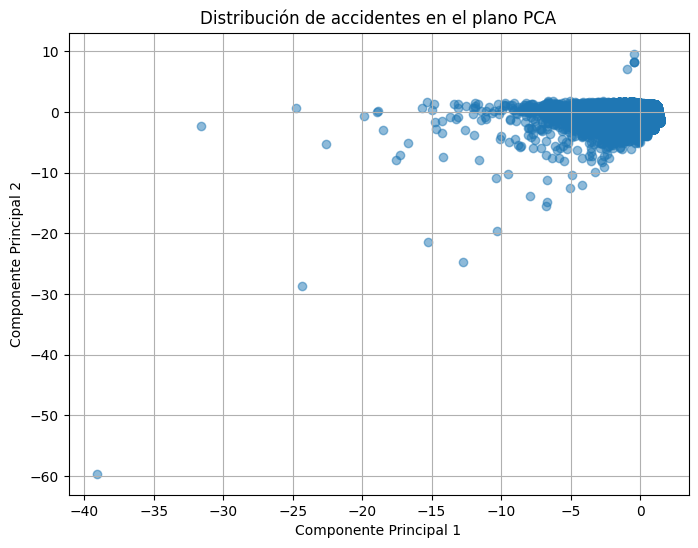

In [43]:
# Convertir a Pandas
df_plot = df_pca.select("pca_features").toPandas()

# Separar componentes
df_plot["PC1"] = df_plot["pca_features"].apply(lambda x: x[0])
df_plot["PC2"] = df_plot["pca_features"].apply(lambda x: x[1])

# Graficar
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df_plot["PC1"], df_plot["PC2"], alpha=0.5)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Distribución de accidentes en el plano PCA")
plt.grid(True)
plt.show()


### Análisis del PCA (gráfico)

El gráfico muestra la proyección de los accidentes en 2 componentes principales:
Patrones visuales identificables:

Cluster denso principal (centro-derecha del gráfico):

La mayoría de accidentes se agrupan entre PC1 = -5 a 2, PC2 = -5 a 2
Representa accidentes "típicos" o comunes


Outliers notables:
Extremo superior derecho (PC1 ≈ 0, PC2 ≈ 8-10): 2-3 accidentes muy atípicos
Extremo izquierdo (PC1 ≈ -35, PC2 ≈ -7): 1 accidente excepcional
Izquierda media (PC1 ≈ -30 a -20): Algunos casos raros


Dispersión gradual:
Hay una "cola" de puntos que se dispersan hacia la izquierda y arriba
Sugiere variabilidad en ciertos tipos de accidentes

## Segmentacion

k=2, WSSSE=470070.3948533017


k=3, WSSSE=418612.7503874654


k=4, WSSSE=335722.62602923036


k=5, WSSSE=324054.75436301687


k=6, WSSSE=267070.84790099924
k=7, WSSSE=249171.89089771578


k=8, WSSSE=211988.6053651582


k=9, WSSSE=203701.01988764966


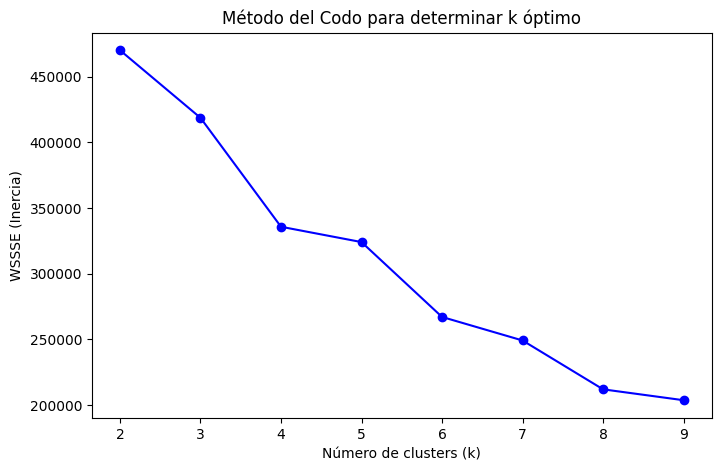

In [44]:


# --- Columnas numéricas ---
num_cols = [col for col in df_scaled.columns if col not in ['mes_ocu','depto_ocu','mupio_ocu','features','scaled_features']]

# --- VectorAssembler y escalado ya hecho (df_scaled) ---

# --- Probar distintos valores de k ---
wssse_list = []
k_values = list(range(2, 10))  # probar de 2 a 9 clusters

for k in k_values:
    kmeans = KMeans(featuresCol="scaled_features", k=k, seed=42)
    model = kmeans.fit(df_scaled)
    wssse = model.summary.trainingCost
    wssse_list.append(wssse)
    print(f"k={k}, WSSSE={wssse}")

# --- Graficar Elbow Method ---
plt.figure(figsize=(8,5))
plt.plot(k_values, wssse_list, 'bo-')
plt.xlabel("Número de clusters (k)")
plt.ylabel("WSSSE (Inercia)")
plt.title("Método del Codo para determinar k óptimo")
plt.show()


El mejor k es el de 6.


In [46]:
# --- KMeans ---
from pyspark.sql.functions import col, mean
from pyspark.sql.types import DoubleType

k = 6
kmeans = KMeans(featuresCol="scaled_features", predictionCol="cluster", k=k, seed=42)
model = kmeans.fit(df_scaled)
df_clusters = model.transform(df_scaled)

# --- Mostrar conteo de accidentes por clúster ---
df_clusters.groupBy("cluster").count().show()

# --- Caracterizar cada clúster: promedio de variables numéricas ---
for col_name in num_cols:
    df_clusters = df_clusters.withColumn(col_name, col(col_name).cast(DoubleType()))

df_clusters.groupBy("cluster").agg(*[mean(c).alias(c+"_mean") for c in num_cols]).show()


+-------+-----+
|cluster|count|
+-------+-----+
|      1| 2032|
|      3|21089|
|      5|17960|
|      4|16540|
|      2|17420|
|      0|13609|
+-------+-----+

+-------+------------------+------------------+------------------+----------------------------------+--------------------+-------------------+
|cluster|      dia_ocu_mean|     hora_ocu_mean|      año_ocu_mean|numero_vehiculos_involucrados_mean|     fallecidos_mean|    lesionados_mean|
+-------+------------------+------------------+------------------+----------------------------------+--------------------+-------------------+
|      1|15.398129921259843|13.816929133858268|2018.6614173228347|                 2.043799212598425|  0.2327755905511811| 1.3823818897637796|
|      3|15.463559201479445| 16.09758641946038|2014.9995732372327|                               1.0|0.008630091516904548| 1.3655934373370002|
|      5|23.871046770601335| 16.59827394209354|2021.1167037861915|                               1.0|0.005178173719376392| 0


### **Cluster 0 — Alta mortalidad, baja frecuencia**

| Variable                             | Valor medio      |
| ------------------------------------ | ---------------- |
| `fallecidos_mean`                    | 1.14             |
| `lesionados_mean`                    | 0.40             |
| `numero_vehiculos_involucrados_mean` | 1.0              |
| `hora_ocu_mean`                      | 14.5 (2:30 p.m.) |
| `año_ocu_mean`                       | 2018.65          |

**Interpretación:**
Este clúster representa accidentes con alta letalidad (más de un fallecido por evento), pocos lesionados y un solo vehículo involucrado. Probablemente son accidentes individuales graves, como choques contra objetos fijos o caídas de motociclistas.
**Severidad: Alta.**

---

### **Cluster 1 — Accidentes múltiples y de mediana gravedad**

| Variable                             | Valor medio      |
| ------------------------------------ | ---------------- |
| `numero_vehiculos_involucrados_mean` | 2.04             |
| `fallecidos_mean`                    | 0.23             |
| `lesionados_mean`                    | 1.38             |
| `hora_ocu_mean`                      | 13.8 (1:50 p.m.) |
| `año_ocu_mean`                       | 2018.7           |

**Interpretación:**
Agrupa accidentes con más de un vehículo (colisiones), algunos lesionados y pocos fallecidos. Corresponde a accidentes moderados, típicos de zonas urbanas o interurbanas.
**Severidad: Moderada.**

---

### **Cluster 2 — Accidentes recientes y leves**

| Variable                             | Valor medio      |
| ------------------------------------ | ---------------- |
| `año_ocu_mean`                       | 2021.18          |
| `fallecidos_mean`                    | 0.008            |
| `lesionados_mean`                    | 0.89             |
| `numero_vehiculos_involucrados_mean` | 1.0              |
| `hora_ocu_mean`                      | 16.7 (4:40 p.m.) |

**Interpretación:**
Accidentes recientes, casi sin fallecidos y con menos de un lesionado promedio. Representan casos leves, probablemente choques menores o incidentes con daños materiales.
**Severidad: Baja.**

---

### **Cluster 3 — Accidentes antiguos, con lesiones leves**

| Variable                             | Valor medio |
| ------------------------------------ | ----------- |
| `año_ocu_mean`                       | 2015.0      |
| `fallecidos_mean`                    | 0.009       |
| `lesionados_mean`                    | 1.37        |
| `numero_vehiculos_involucrados_mean` | 1.0         |

**Interpretación:**
Agrupa accidentes antiguos (entre 2013 y 2016), con muy pocos fallecidos pero con más de un lesionado en promedio. Representa incidentes moderados o leves registrados en años anteriores.
**Severidad: Baja a moderada.**

---

### **Cluster 4 — Accidentes nocturnos o de madrugada**

| Variable                             | Valor medio      |
| ------------------------------------ | ---------------- |
| `hora_ocu_mean`                      | 3.18 (3:10 a.m.) |
| `fallecidos_mean`                    | 0.10             |
| `lesionados_mean`                    | 0.81             |
| `numero_vehiculos_involucrados_mean` | 1.0              |
| `año_ocu_mean`                       | 2019.4           |

**Interpretación:**
Accidentes ocurridos de madrugada, generalmente con un solo vehículo involucrado, pocos lesionados y pocos fallecidos. Pueden estar relacionados con fatiga, velocidad o consumo de alcohol.
**Severidad: Moderada.**

---

### **Cluster 5 — Accidentes recientes y leves**

| Variable                             | Valor medio      |
| ------------------------------------ | ---------------- |
| `año_ocu_mean`                       | 2021.12          |
| `fallecidos_mean`                    | 0.005            |
| `lesionados_mean`                    | 0.91             |
| `numero_vehiculos_involucrados_mean` | 1.0              |
| `hora_ocu_mean`                      | 16.6 (4:35 p.m.) |

**Interpretación:**
Accidentes recientes, con prácticamente ningún fallecido y menos de un lesionado por evento. Representa la mayoría de accidentes leves registrados en los años más recientes.
**Severidad: Baja.**

---

### **Resumen general**

| Cluster | Tipo de accidente                      | Severidad | Características principales           |
| ------- | -------------------------------------- | --------- | ------------------------------------- |
| 0       | Accidentes individuales con fallecidos | Alta      | 1 vehículo, más de 1 fallecido        |
| 1       | Colisiones entre varios vehículos      | Moderada  | 2 o más vehículos, algunos lesionados |
| 2       | Accidentes recientes leves             | Baja      | 1 vehículo, sin fallecidos            |
| 3       | Accidentes antiguos leves              | Baja      | 1 vehículo, 1 lesionado               |
| 4       | Accidentes nocturnos                   | Moderada  | 1 vehículo, madrugada                 |
| 5       | Accidentes recientes leves             | Baja      | 1 vehículo, pocos lesionados          |

---


## MODELADO SUPERVISADO PARA PREDICCIÓN 

In [50]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "severidad",
    when((col("fallecidos") == 0) & (col("lesionados") < 2), "Leve")
    .when((col("fallecidos") == 1) | ((col("lesionados") >= 2) & (col("lesionados") <= 5)), "Moderado")
    .when((col("fallecidos") > 1) | (col("lesionados") > 5), "Grave")
    .otherwise("Desconocido")
)

# --- Mostrar ejemplo de clasificación ---
df.select("fallecidos", "lesionados", "severidad").show(15)

# --- Guardar con la nueva columna ---
salida = "../working_dir/Datos_Accidentes_2013_2023_Severidad.csv"
df.write.csv(salida, header=True, mode="overwrite")

print(f"Archivo guardado con nueva columna en: {salida}")

+----------+----------+---------+
|fallecidos|lesionados|severidad|
+----------+----------+---------+
|       1.0|       0.0| Moderado|
|       0.0|       1.0|     Leve|
|       0.0|       1.0|     Leve|
|       1.0|       1.0| Moderado|
|       1.0|       0.0| Moderado|
|       0.0|       1.0|     Leve|
|       0.0|       0.0|     Leve|
|       0.0|       1.0|     Leve|
|       1.0|       0.0| Moderado|
|       0.0|       1.0|     Leve|
|       0.0|       1.0|     Leve|
|       5.0|       1.0|    Grave|
|       0.0|      10.0|    Grave|
|       1.0|       0.0| Moderado|
|       0.0|       0.0|     Leve|
+----------+----------+---------+
only showing top 15 rows



[Stage 2256:>                                                       (0 + 1) / 1]

Archivo guardado con nueva columna en: ../working_dir/Datos_Accidentes_2013_2023_Severidad.csv


### Dividir datos

In [77]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
import math

# --- Iniciar Spark ---
spark = SparkSession.builder.appName("Balanceo_Severidad_2023").getOrCreate()

# --- Cargar datos generales ---
archivo = "../working_dir/Datos_Accidentes_2013_2023_Severidad.csv"
df = spark.read.csv(archivo, header=True, inferSchema=True)

# --- Filtrar solo accidentes de 2023 ---
df_2023 = df.filter(col("año_ocu") == 2023)

# --- Ver distribución original de 2023 ---
print("Distribución original 2023:")
df_2023.groupBy("severidad").count().show()

# --- Calcular el tamaño máximo (clase mayoritaria) ---
class_counts = df_2023.groupBy("severidad").count().collect()
max_count = max([row["count"] for row in class_counts])

# --- Sobremuestreo por clase ---
balanced_dfs = []
for row in class_counts:
    clase = row["severidad"]
    count = row["count"]
    factor = math.ceil(max_count / count)
    
    subset = df_2023.filter(col("severidad") == clase)
    oversampled = subset
    for _ in range(factor - 1):
        oversampled = oversampled.union(subset)
    
    oversampled = oversampled.limit(max_count)
    balanced_dfs.append(oversampled)

# --- Unir todas las clases balanceadas ---
df_2023_balanced = balanced_dfs[0]
for b in balanced_dfs[1:]:
    df_2023_balanced = df_2023_balanced.union(b)

print("Distribución balanceada 2023:")
df_2023_balanced.groupBy("severidad").count().show()

# --- Dividir en train/test 70/30 para 2023 ---
train_2023_df, test_2023_df = df_2023_balanced.randomSplit([0.7, 0.3], seed=42)

print("Distribución en entrenamiento 2023:")
train_2023_df.groupBy("severidad").count().show()

print("Distribución en prueba 2023:")
test_2023_df.groupBy("severidad").count().show()

# --- Guardar resultados ---
train_2023_df.write.csv("../working_dir/Accidentes_train_2023_balanceado.csv", header=True, mode="overwrite")
test_2023_df.write.csv("../working_dir/Accidentes_test_2023_balanceado.csv", header=True, mode="overwrite")

print("✅ Dataset 2023 balanceado y dividido correctamente.")


25/10/13 00:01:20 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
                                                                                

Distribución original 2023:
+---------+-----+
|severidad|count|
+---------+-----+
| Moderado| 3365|
|     Leve|11411|
|    Grave|  245|
+---------+-----+

Distribución balanceada 2023:


+---------+-----+
|severidad|count|
+---------+-----+
| Moderado|11411|
|     Leve|11411|
|    Grave|11411|
+---------+-----+

Distribución en entrenamiento 2023:


+---------+-----+
|severidad|count|
+---------+-----+
| Moderado| 8084|
|     Leve| 8021|
|    Grave| 7983|
+---------+-----+

Distribución en prueba 2023:


+---------+-----+
|severidad|count|
+---------+-----+
| Moderado| 3327|
|     Leve| 3390|
|    Grave| 3428|
+---------+-----+



[Stage 3289:============================================>         (39 + 4) / 47]

✅ Dataset 2023 balanceado y dividido correctamente.


In [79]:
print("Columnas del dataset balanceado:")
print(df_balanced.columns)


Columnas del dataset balanceado:
['dia_ocu', 'mes_ocu', 'hora_ocu', 'depto_ocu', 'mupio_ocu', 'año_ocu', 'numero_vehiculos_involucrados', 'fallecidos', 'lesionados', 'severidad']


### Pipeline de clasificacion

In [106]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# --- Iniciar Spark ---
spark = SparkSession.builder.appName("RF_Accidentes_Mejorado").getOrCreate()

# --- Cargar dataset balanceado ---
archivo_train = "../working_dir/Accidentes_train_balanceado.csv"
archivo_test = "../working_dir/Accidentes_test_balanceado.csv"
train_df = spark.read.csv(archivo_train, header=True, inferSchema=True)
test_df = spark.read.csv(archivo_test, header=True, inferSchema=True)

# --- Features derivadas ---
def agregar_features(df):
    df = df.withColumn("hora_rango", 
                       when((col("hora_ocu") >= 0) & (col("hora_ocu") <= 5), "madrugada")
                       .when((col("hora_ocu") >= 6) & (col("hora_ocu") <= 11), "mañana")
                       .when((col("hora_ocu") >= 12) & (col("hora_ocu") <= 17), "tarde")
                       .otherwise("noche"))
    df = df.withColumn("vehiculos_mas_1", when(col("numero_vehiculos_involucrados") > 1, 1).otherwise(0))
    df = df.withColumn("lesionados_mas_1", when(col("lesionados") > 1, 1).otherwise(0))
    df = df.withColumn("fallecidos_mas_0", when(col("fallecidos") > 0, 1).otherwise(0))
    return df

train_df = agregar_features(train_df)
test_df = agregar_features(test_df)

# --- Asegurar tipos numéricos ---
num_cols = ['dia_ocu', 'mes_ocu', 'hora_ocu', 'año_ocu', 
            'numero_vehiculos_involucrados',
            'vehiculos_mas_1', 'lesionados_mas_1', 'fallecidos_mas_0']
for c in num_cols:
    train_df = train_df.withColumn(c, col(c).cast(DoubleType()))
    test_df = test_df.withColumn(c, col(c).cast(DoubleType()))

# --- Variables categóricas ---
cat_cols = ['depto_ocu', 'mupio_ocu', 'hora_rango']

# --- Indexar variables categóricas ---
indexers = [StringIndexer(inputCol=c, outputCol=c+"_index", handleInvalid="keep") for c in cat_cols]

# --- Indexar la variable objetivo ---
label_indexer = StringIndexer(inputCol='severidad', outputCol='label', handleInvalid="keep")

# --- VectorAssembler ---
feature_cols = num_cols + [c+"_index" for c in cat_cols]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")

# --- StandardScaler ---
scaler = StandardScaler(inputCol="features_raw", outputCol="features")

# --- RandomForestClassifier ---
rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=42)

# --- Pipeline completo ---
pipeline = Pipeline(stages=indexers + [label_indexer, assembler, scaler, rf])

# --- Entrenar modelo ---
model = pipeline.fit(train_df)

# --- Predecir en conjunto de prueba ---
predictions = model.transform(test_df)

# --- Evaluación ---
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

accuracy = evaluator_acc.evaluate(predictions)
f1 = evaluator_f1.evaluate(predictions)
precision = evaluator_precision.evaluate(predictions)
recall = evaluator_recall.evaluate(predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# --- Guardar pipeline completo entrenado de Random Forest ---
model.write().overwrite().save("../working_dir/Modelos/RandomForest_Model")

print("Modelo Random Forest guardado correctamente en ../working_dir/Modelos/RandomForest_Model")


25/10/13 00:19:32 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Accuracy: 0.7415
F1-score: 0.7394
Precision: 0.7442
Recall: 0.7415
Modelo Random Forest guardado correctamente en ../working_dir/Modelos/RandomForest_Model


### Comparacion

In [83]:
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier
from pyspark.sql import SparkSession
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

# --- Reutilizamos train_df y test_df del código anterior ---
modelos = {
    "RandomForest": RandomForestClassifier(featuresCol="features", labelCol="label", seed=42),
    "LogisticRegression": LogisticRegression(featuresCol="features", labelCol="label", maxIter=50),
    "DecisionTree": DecisionTreeClassifier(featuresCol="features", labelCol="label", seed=42)
}

resultados = []

for nombre, modelo in modelos.items():
    # Construir pipeline
    pipeline = Pipeline(stages=indexers + [label_indexer, assembler, scaler, modelo])
    
    # Entrenar
    modelo_fit = pipeline.fit(train_df)
    
    # Predecir
    predicciones = modelo_fit.transform(test_df)
    
    # Evaluar
    evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
    evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
    evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
    evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")
    
    resultados.append({
        "Modelo": nombre,
        "Accuracy": evaluator_acc.evaluate(predicciones),
        "F1-score": evaluator_f1.evaluate(predicciones),
        "Precision": evaluator_precision.evaluate(predicciones),
        "Recall": evaluator_recall.evaluate(predicciones)
    })

# --- Mostrar resultados como tabla ---
import pandas as pd
df_resultados = pd.DataFrame(resultados)
print(df_resultados)


               Modelo  Accuracy  F1-score  Precision    Recall
0        RandomForest  0.741541  0.739441   0.744194  0.741541
1  LogisticRegression  0.692981  0.692443   0.693118  0.692981
2        DecisionTree  0.735317  0.733585   0.737288  0.735317


Como podemos ver el mejor modelo fue el Random Forest esto se debe a que

- Puede capturar interacciones complejas entre variables (por ejemplo, número de vehículos involucrados, hora del accidente, día del mes, etc.).
- Es robusto ante ruido y valores atípicos, algo importante en datos de accidentes que pueden ser muy heterogéneos.
    

### Modelo lineal

In [105]:
# ----------------------------
# Modelo de Regresión Lineal
# ----------------------------

from pyspark.sql import SparkSession
from pyspark.sql.functions import when, col
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

# --- 1️⃣ Iniciar Spark ---
spark = SparkSession.builder.appName("RegresionFallecidos_Limpio").getOrCreate()

# --- 2️⃣ Cargar CSV limpio ---
archivo = "../working_dir/Datos_Accidentes_2013_2023_Limpio.csv"
df_lr = spark.read.csv(archivo, header=True, inferSchema=True)

# --- 3️⃣ Definir columnas ---
cat_cols_lr = ['depto_ocu', 'mupio_ocu']  # categóricas
num_cols_lr = ['hora_ocu', 'numero_vehiculos_involucrados', 'lesionados']  # numéricas
target_col_lr = 'fallecidos'

# Mantener solo filas completas
df_lr = df_lr.select(cat_cols_lr + num_cols_lr + [target_col_lr]).dropna()

# Asegurar tipos numéricos
for c in num_cols_lr + [target_col_lr]:
    df_lr = df_lr.withColumn(c, col(c).cast(DoubleType()))

# --- 4️⃣ Indexar variables categóricas ---
indexers_lr = [StringIndexer(inputCol=c, outputCol=c+"_index", handleInvalid="keep") for c in cat_cols_lr]
df_lr = df_lr.dropna(subset=num_cols_lr + cat_cols_lr + [target_col_lr])

# --- 5️⃣ VectorAssembler y StandardScaler ---
feature_cols_lr = num_cols_lr + [c+"_index" for c in cat_cols_lr]
assembler_lr = VectorAssembler(inputCols=feature_cols_lr, outputCol="features_raw")
scaler_lr = StandardScaler(inputCol="features_raw", outputCol="features")

# --- 6️⃣ Linear Regression ---
lr_model_pipeline = LinearRegression(featuresCol="features", labelCol=target_col_lr)

# --- 7️⃣ Pipeline completo ---
pipeline_lr = Pipeline(stages=indexers_lr + [assembler_lr, scaler_lr, lr_model_pipeline])

# --- 8️⃣ Separar train/test ---
train_df_lr, test_df_lr = df_lr.randomSplit([0.8, 0.2], seed=42)

# --- 9️⃣ Entrenar modelo ---
model_lr = pipeline_lr.fit(train_df_lr)

# --- 🔟 Predecir ---
predictions_lr = model_lr.transform(test_df_lr)
predictions_lr.select(target_col_lr, "prediction").show(10)

# --- 11️⃣ Evaluación ---
evaluator_rmse_lr = RegressionEvaluator(labelCol=target_col_lr, predictionCol="prediction", metricName="rmse")
evaluator_mae_lr  = RegressionEvaluator(labelCol=target_col_lr, predictionCol="prediction", metricName="mae")
evaluator_r2_lr   = RegressionEvaluator(labelCol=target_col_lr, predictionCol="prediction", metricName="r2")

rmse_lr = evaluator_rmse_lr.evaluate(predictions_lr)
mae_lr  = evaluator_mae_lr.evaluate(predictions_lr)
r2_lr   = evaluator_r2_lr.evaluate(predictions_lr)

print(f"RMSE: {rmse_lr:.3f}")
print(f"MAE: {mae_lr:.3f}")
print(f"R²: {r2_lr:.3f}")

# --- 12️⃣ Guardar modelo entrenado ---
model_lr.write().overwrite().save("../working_dir/Modelos/LinearRegression_Model")


25/10/13 00:18:31 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
25/10/13 00:18:33 WARN Instrumentation: [f92f5a69] regParam is zero, which might cause numerical instability and overfitting.
                                                                                

+----------+-------------------+
|fallecidos|         prediction|
+----------+-------------------+
|       0.0|0.19691813928530846|
|       0.0|0.19691813928530846|
|       0.0|0.19691813928530846|
|       0.0|0.19691813928530846|
|       0.0|0.19691813928530846|
|       0.0|0.19691813928530846|
|       0.0|0.19691813928530846|
|       0.0|0.19691813928530846|
|       0.0|0.19691813928530846|
|       0.0|0.19691813928530846|
+----------+-------------------+
only showing top 10 rows

RMSE: 0.519
MAE: 0.337
R²: 0.012


Podemos ver que nuestro modelo fue bastante malo. de hecho no pudo predecir muy bien.

### Prediccion

In [104]:
# Guardar el pipeline completo entrenado



NameError: name 'pipeline_rf' is not defined

In [108]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.ml import PipelineModel
from pyspark.sql.types import DoubleType

# --- 1️⃣ Iniciar Spark ---
spark = SparkSession.builder.appName("Prediccion_RF_2023").getOrCreate()

# --- 2️⃣ Cargar nuevos datasets ---
archivo_train = "../working_dir/Accidentes_train_2023_balanceado.csv"
archivo_test  = "../working_dir/Accidentes_test_2023_balanceado.csv"

train_df_2023 = spark.read.csv(archivo_train, header=True, inferSchema=True)
test_df_2023  = spark.read.csv(archivo_test, header=True, inferSchema=True)

# --- 3️⃣ Agregar features derivadas (igual que en el pipeline original) ---
def agregar_features(df):
    df = df.withColumn("hora_rango", 
                       when((col("hora_ocu") >= 0) & (col("hora_ocu") <= 5), "madrugada")
                       .when((col("hora_ocu") >= 6) & (col("hora_ocu") <= 11), "mañana")
                       .when((col("hora_ocu") >= 12) & (col("hora_ocu") <= 17), "tarde")
                       .otherwise("noche"))
    df = df.withColumn("vehiculos_mas_1", when(col("numero_vehiculos_involucrados") > 1, 1).otherwise(0))
    df = df.withColumn("lesionados_mas_1", when(col("lesionados") > 1, 1).otherwise(0))
    df = df.withColumn("fallecidos_mas_0", when(col("fallecidos") > 0, 1).otherwise(0))
    return df

train_df_2023 = agregar_features(train_df_2023)
test_df_2023  = agregar_features(test_df_2023)

# --- 4️⃣ Asegurar tipos numéricos ---
num_cols = ['dia_ocu', 'mes_ocu', 'hora_ocu', 'año_ocu', 
            'numero_vehiculos_involucrados',
            'vehiculos_mas_1', 'lesionados_mas_1', 'fallecidos_mas_0']

for c in num_cols:
    train_df_2023 = train_df_2023.withColumn(c, col(c).cast(DoubleType()))
    test_df_2023  = test_df_2023.withColumn(c, col(c).cast(DoubleType()))

# --- 5️⃣ Cargar pipeline entrenado ---
model_rf = PipelineModel.load("../working_dir/Modelos/RandomForest_Model")

# --- 6️⃣ Predecir ---
predicciones_train = model_rf.transform(train_df_2023)
predicciones_test  = model_rf.transform(test_df_2023)

# --- 7️⃣ Mostrar algunas predicciones ---
predicciones_test.select("severidad", "prediction").show(10)

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# --- Evaluadores ---
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

# --- Evaluar sobre conjunto de prueba ---
accuracy = evaluator_acc.evaluate(predicciones_test)
f1 = evaluator_f1.evaluate(predicciones_test)
precision = evaluator_precision.evaluate(predicciones_test)
recall = evaluator_recall.evaluate(predicciones_test)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")



+---------+----------+
|severidad|prediction|
+---------+----------+
| Moderado|       2.0|
| Moderado|       1.0|
| Moderado|       1.0|
| Moderado|       1.0|
| Moderado|       1.0|
| Moderado|       1.0|
| Moderado|       1.0|
| Moderado|       1.0|
| Moderado|       1.0|
| Moderado|       1.0|
+---------+----------+
only showing top 10 rows

Accuracy: 0.7594
F1-score: 0.7539
Precision: 0.7664
Recall: 0.7594


In [110]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.sql.types import DoubleType
from pyspark.ml import PipelineModel
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, RegressionEvaluator

# --- 1️⃣ Iniciar Spark ---
spark = SparkSession.builder.appName("Prediccion_RF_LR_2023").getOrCreate()

# --- 2️⃣ Cargar nuevos datasets ---
archivo_train = "../working_dir/Accidentes_train_2023_balanceado.csv"
archivo_test  = "../working_dir/Accidentes_test_2023_balanceado.csv"

train_df = spark.read.csv(archivo_train, header=True, inferSchema=True)
test_df  = spark.read.csv(archivo_test, header=True, inferSchema=True)

# --- 3️⃣ Agregar features derivadas ---
def agregar_features_clasificacion(df):
    df = df.withColumn("hora_rango", 
                       when((col("hora_ocu") >= 0) & (col("hora_ocu") <= 5), "madrugada")
                       .when((col("hora_ocu") >= 6) & (col("hora_ocu") <= 11), "mañana")
                       .when((col("hora_ocu") >= 12) & (col("hora_ocu") <= 17), "tarde")
                       .otherwise("noche"))
    df = df.withColumn("vehiculos_mas_1", when(col("numero_vehiculos_involucrados") > 1, 1).otherwise(0))
    df = df.withColumn("lesionados_mas_1", when(col("lesionados") > 1, 1).otherwise(0))
    df = df.withColumn("fallecidos_mas_0", when(col("fallecidos") > 0, 1).otherwise(0))
    return df

train_df = agregar_features_clasificacion(train_df)
test_df  = agregar_features_clasificacion(test_df)

# --- 4️⃣ Asegurar tipos numéricos ---
num_cols = ['dia_ocu', 'mes_ocu', 'hora_ocu', 'año_ocu', 
            'numero_vehiculos_involucrados',
            'vehiculos_mas_1', 'lesionados_mas_1', 'fallecidos_mas_0']

for c in num_cols:
    train_df = train_df.withColumn(c, col(c).cast(DoubleType()))
    test_df  = test_df.withColumn(c, col(c).cast(DoubleType()))

# ---------------------------
# 🔹 Predicción Random Forest
# ---------------------------
print("\n--- Random Forest: Clasificación ---")

# Cargar modelo
model_rf = PipelineModel.load("../working_dir/Modelos/RandomForest_Model")

# Predecir
predicciones_train_rf = model_rf.transform(train_df)
predicciones_test_rf  = model_rf.transform(test_df)

# Mostrar algunas predicciones
predicciones_test_rf.select("severidad", "prediction").show(10)

# Evaluación
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

accuracy = evaluator_acc.evaluate(predicciones_test_rf)
f1 = evaluator_f1.evaluate(predicciones_test_rf)
precision = evaluator_precision.evaluate(predicciones_test_rf)
recall = evaluator_recall.evaluate(predicciones_test_rf)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# ---------------------------
# 🔹 Predicción Linear Regression
# ---------------------------
print("\n--- Linear Regression: Regresión ---")

# Definir columnas para regresión
cat_cols_lr = ['depto_ocu', 'mupio_ocu']
num_cols_lr = ['hora_ocu', 'numero_vehiculos_involucrados', 'lesionados']
target_col_lr = 'fallecidos'

# Mantener solo filas completas y asegurar tipos
train_df_lr = train_df.select(cat_cols_lr + num_cols_lr + [target_col_lr]).dropna()
test_df_lr  = test_df.select(cat_cols_lr + num_cols_lr + [target_col_lr]).dropna()

for c in num_cols_lr + [target_col_lr]:
    train_df_lr = train_df_lr.withColumn(c, col(c).cast(DoubleType()))
    test_df_lr  = test_df_lr.withColumn(c, col(c).cast(DoubleType()))

# Agregar features derivadas (solo flags, sin hora_rango)
def agregar_features_regresion(df):
    df = df.withColumn("vehiculos_mas_1", when(col("numero_vehiculos_involucrados") > 1, 1).otherwise(0))
    df = df.withColumn("lesionados_mas_1", when(col("lesionados") > 1, 1).otherwise(0))
    df = df.withColumn("fallecidos_mas_0", when(col("fallecidos") > 0, 1).otherwise(0))
    return df

train_df_lr = agregar_features_regresion(train_df_lr)
test_df_lr  = agregar_features_regresion(test_df_lr)

# Cargar pipeline de regresión
model_lr = PipelineModel.load("../working_dir/Modelos/LinearRegression_Model")

# Predecir
predicciones_train_lr = model_lr.transform(train_df_lr)
predicciones_test_lr  = model_lr.transform(test_df_lr)

# Mostrar algunas predicciones
predicciones_test_lr.select(target_col_lr, "prediction").show(10)

# Evaluación
evaluator_rmse = RegressionEvaluator(labelCol=target_col_lr, predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(labelCol=target_col_lr, predictionCol="prediction", metricName="mae")
evaluator_r2   = RegressionEvaluator(labelCol=target_col_lr, predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(predicciones_test_lr)
mae  = evaluator_mae.evaluate(predicciones_test_lr)
r2   = evaluator_r2.evaluate(predicciones_test_lr)

print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R²: {r2:.3f}")


25/10/13 00:22:28 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.



--- Random Forest: Clasificación ---
+---------+----------+
|severidad|prediction|
+---------+----------+
| Moderado|       2.0|
| Moderado|       1.0|
| Moderado|       1.0|
| Moderado|       1.0|
| Moderado|       1.0|
| Moderado|       1.0|
| Moderado|       1.0|
| Moderado|       1.0|
| Moderado|       1.0|
| Moderado|       1.0|
+---------+----------+
only showing top 10 rows

Accuracy: 0.7594
F1-score: 0.7539
Precision: 0.7664
Recall: 0.7594

--- Linear Regression: Regresión ---
+----------+-------------------+
|fallecidos|         prediction|
+----------+-------------------+
|       0.0|0.20111177875768482|
|       1.0|0.24122126745671557|
|       1.0|0.29840796795749336|
|       1.0|0.29840796795749336|
|       1.0|0.22713739791111004|
|       1.0|0.22713739791111004|
|       1.0|0.22713739791111004|
|       0.0|0.28457767806646017|
|       1.0|0.16612831877869907|
|       1.0|0.16612831877869907|
+----------+-------------------+
only showing top 10 rows

RMSE: 1.079
MAE: 0.71

#### Analisis




### Graficar

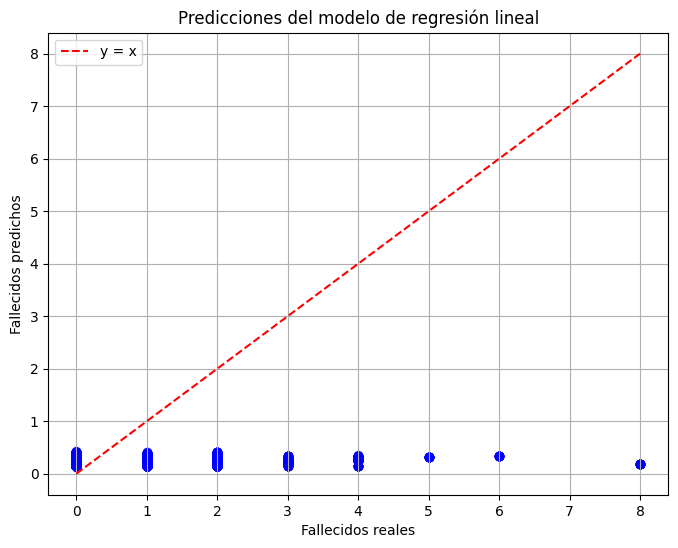

In [114]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1️⃣ Seleccionar solo columnas de interés y convertir a Pandas ---
df_plot = predicciones_test_lr.select(target_col_lr, "prediction").toPandas()

# --- 2️⃣ Graficar predicho vs real ---
plt.figure(figsize=(8, 6))
plt.scatter(df_plot[target_col_lr], df_plot["prediction"], alpha=0.5, color="blue")
plt.plot([df_plot[target_col_lr].min(), df_plot[target_col_lr].max()],
         [df_plot[target_col_lr].min(), df_plot[target_col_lr].max()],
         color="red", linestyle="--", label="y = x")
plt.xlabel("Fallecidos reales")
plt.ylabel("Fallecidos predichos")
plt.title("Predicciones del modelo de regresión lineal")
plt.legend()
plt.grid(True)
plt.show()


Podemos ver que no mejoro bastante, lo cual paso debido a que no se incluyeron la mayoria de variables necesarias, o mas colinealidad y cruce entre las mismas que pudo haber propiciado que mejorara mucho mas.